In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# Exploratory Data Overview
Loading the Dataset

In [10]:
file_path = "lung_cancer_dataset.csv"
df = pd.read_csv(file_path)

# Dropping Unnecessary Columns
df = df.drop(columns=["Patient_ID", "Diagnosis_Date"])

# Removing extra white space from columns
df.columns = df.columns.str.strip()

Displaying the First 5 rows of data

In [11]:
df.head()

,Diagnosis_Year,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Secondhand_Smoke,Family_History,...,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,2020,Western Pacific,China,46,Female,Current Smoker,28,28,Yes,No,...,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,2020,Americas,Mexico,71,Male,Former Smoker,5,34,Yes,No,...,No,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,2016,Western Pacific,Japan,53,Female,Never Smoked,0,0,Yes,No,...,No,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,2017,Western Pacific,Singapore,55,Male,Current Smoker,21,34,No,Yes,...,No,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,2023,Western Pacific,Malaysia,54,Male,Never Smoked,0,0,No,No,...,No,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


Brief showcase of data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Diagnosis_Year           1500 non-null   int64  
 1   WHO_Region               1500 non-null   object 
 2   Country                  1500 non-null   object 
 3   Age                      1500 non-null   int64  
 4   Gender                   1500 non-null   object 
 5   Smoking_Status           1500 non-null   object 
 6   Cigarettes_Per_Day       1500 non-null   int64  
 7   Years_Smoking            1500 non-null   int64  
 8   Secondhand_Smoke         1500 non-null   object 
 9   Family_History           1500 non-null   object 
 10  Occupational_Hazard      1500 non-null   object 
 11  Air_Pollution_Exposure   1500 non-null   object 
 12  Alcohol_Use              1500 non-null   object 
 13  BMI                      1500 non-null   float64
 14  Exercise_Frequency      

In [13]:
df.describe()

,Diagnosis_Year,Age,Cigarettes_Per_Day,Years_Smoking,BMI,Tumor_Size_cm,Survival_Months
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2020.630000,60.658000,7.404667,8.214667,26.537267,4.593333,31.150667
std,3.097014,10.298272,11.804087,12.775761,3.977224,2.388304,23.273097
min,2015.000000,30.000000,0.000000,0.000000,16.000000,0.500000,1.000000
25%,2018.000000,53.000000,0.000000,0.000000,23.800000,2.600000,11.000000
50%,2021.000000,60.000000,0.000000,0.000000,26.450000,4.400000,26.000000
75%,2023.000000,68.000000,14.000000,17.000000,29.400000,6.200000,48.000000
max,2025.000000,89.000000,56.000000,59.000000,40.000000,12.900000,109.000000


Checking data types

In [14]:
df.dtypes

Diagnosis_Year               int64
WHO_Region                  object
Country                     object
Age                          int64
Gender                      object
Smoking_Status              object
Cigarettes_Per_Day           int64
Years_Smoking                int64
Secondhand_Smoke            object
Family_History              object
Occupational_Hazard         object
Air_Pollution_Exposure      object
Alcohol_Use                 object
BMI                        float64
Exercise_Frequency          object
Chronic_Lung_Disease        object
Asbestos_Exposure           object
Radon_Exposure              object
Previous_Cancer_History     object
Genetic_Mutation            object
Coughing                    object
Shortness_of_Breath         object
Chest_Pain                  object
Coughing_Blood              object
Fatigue                     object
Weight_Loss                 object
Wheezing                    object
Recurrent_Infections        object
Swallowing_Difficult

Checking columns

In [15]:
df.columns

Index(['Diagnosis_Year', 'WHO_Region', 'Country', 'Age', 'Gender',
       'Smoking_Status', 'Cigarettes_Per_Day', 'Years_Smoking',
       'Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
       'Air_Pollution_Exposure', 'Alcohol_Use', 'BMI', 'Exercise_Frequency',
       'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
       'Previous_Cancer_History', 'Genetic_Mutation', 'Coughing',
       'Shortness_of_Breath', 'Chest_Pain', 'Coughing_Blood', 'Fatigue',
       'Weight_Loss', 'Wheezing', 'Recurrent_Infections',
       'Swallowing_Difficulty', 'Finger_Clubbing', 'Cancer_Type',
       'NSCLC_Subtype', 'Cancer_Stage', 'Tumor_Size_cm', 'Metastasis',
       'Diagnosis_Method', 'Treatment', 'Survival_Months', 'Survived'],
      dtype='object')

Checking for missing values

In [16]:
missing_values = df.isnull().sum()
missing_values

Diagnosis_Year             0
WHO_Region                 0
Country                    0
Age                        0
Gender                     0
Smoking_Status             0
Cigarettes_Per_Day         0
Years_Smoking              0
Secondhand_Smoke           0
Family_History             0
Occupational_Hazard        0
Air_Pollution_Exposure     0
Alcohol_Use                0
BMI                        0
Exercise_Frequency         0
Chronic_Lung_Disease       0
Asbestos_Exposure          0
Radon_Exposure             0
Previous_Cancer_History    0
Genetic_Mutation           0
Coughing                   0
Shortness_of_Breath        0
Chest_Pain                 0
Coughing_Blood             0
Fatigue                    0
Weight_Loss                0
Wheezing                   0
Recurrent_Infections       0
Swallowing_Difficulty      0
Finger_Clubbing            0
Cancer_Type                0
NSCLC_Subtype              0
Cancer_Stage               0
Tumor_Size_cm              0
Metastasis    

Checking for duplicated values

In [17]:
duplicated_values = df.duplicated().sum()
duplicated_values

np.int64(0)

Data Distribution of Target Variable

In [18]:
lung_cancer_survival = df["Survived"].value_counts(normalize=True)
lung_cancer_survival

Survived
No     0.631333
Yes    0.368667
Name: proportion, dtype: float64

Correlation Heatmap

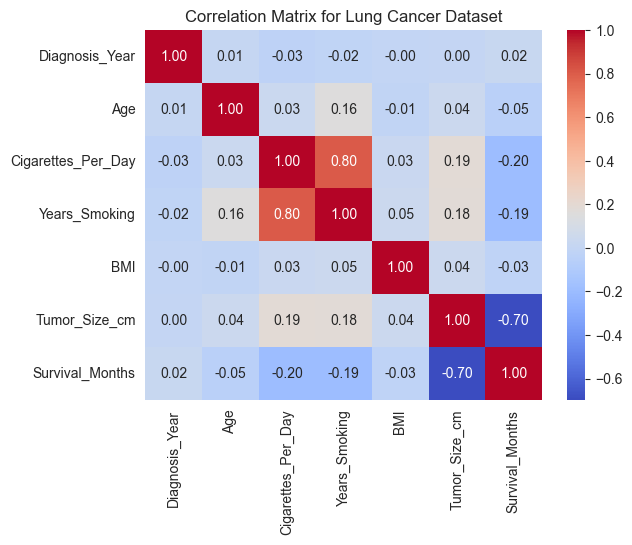

<Figure size 1500x800 with 0 Axes>

In [20]:
df_numerical = df.select_dtypes(include=['int64', 'float64'])

plt.title("Correlation Matrix for Lung Cancer Dataset")
sns.heatmap(df_numerical.corr(), cmap='coolwarm', fmt='.2f', annot=True)
plt.figure(figsize=(15, 8))
plt.show()

Data Distribution of every numerical column

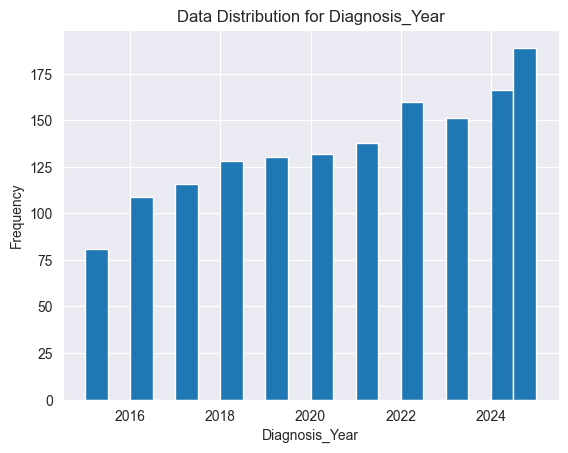

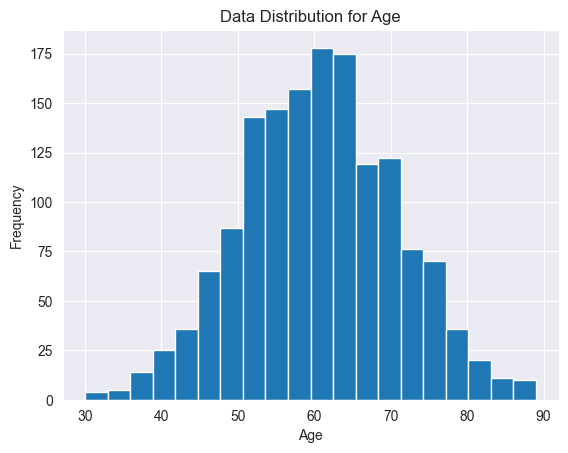

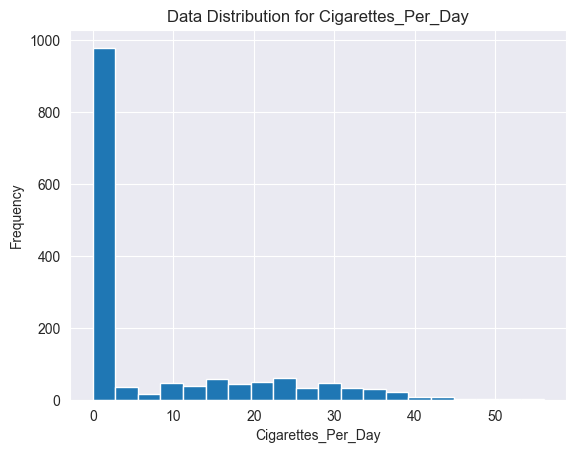

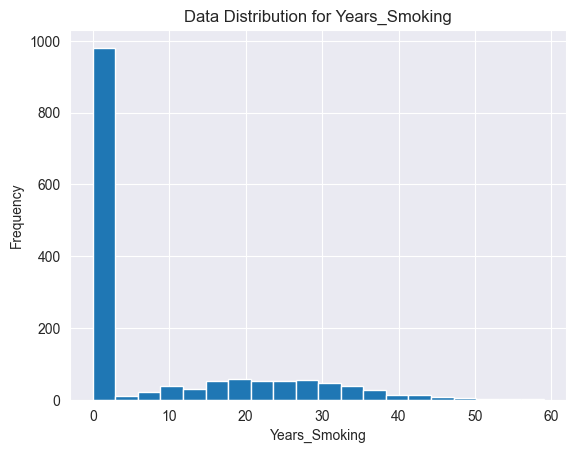

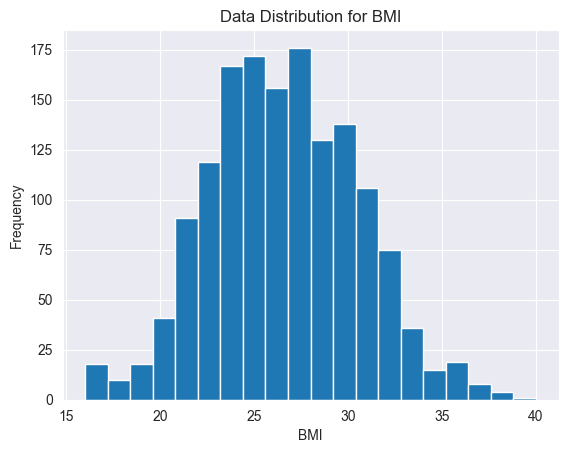

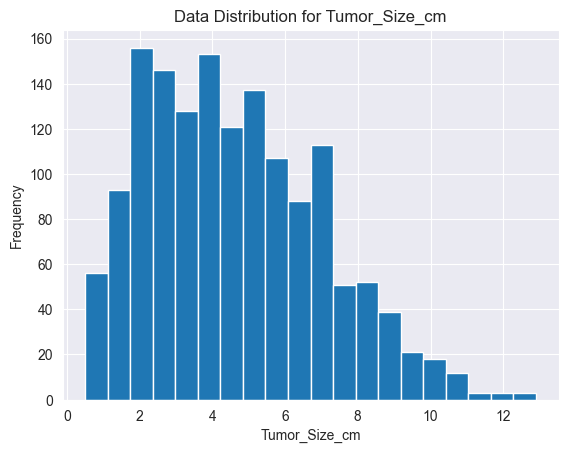

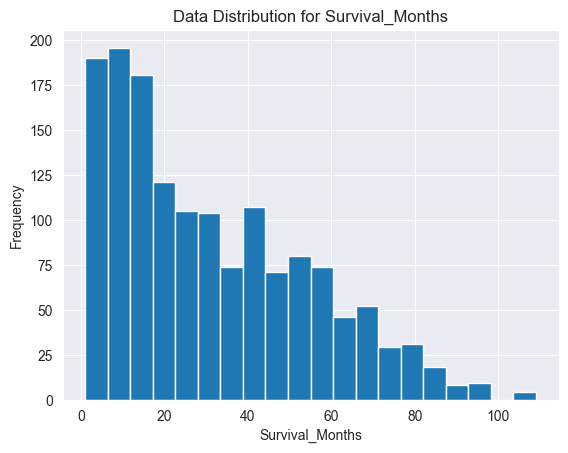

In [21]:
for col in df_numerical.columns:
    plt.hist(df[col], bins=20)
    plt.title(f"Data Distribution for {col}")
    plt.ylabel("Frequency")
    plt.xlabel(col)
    plt.show()

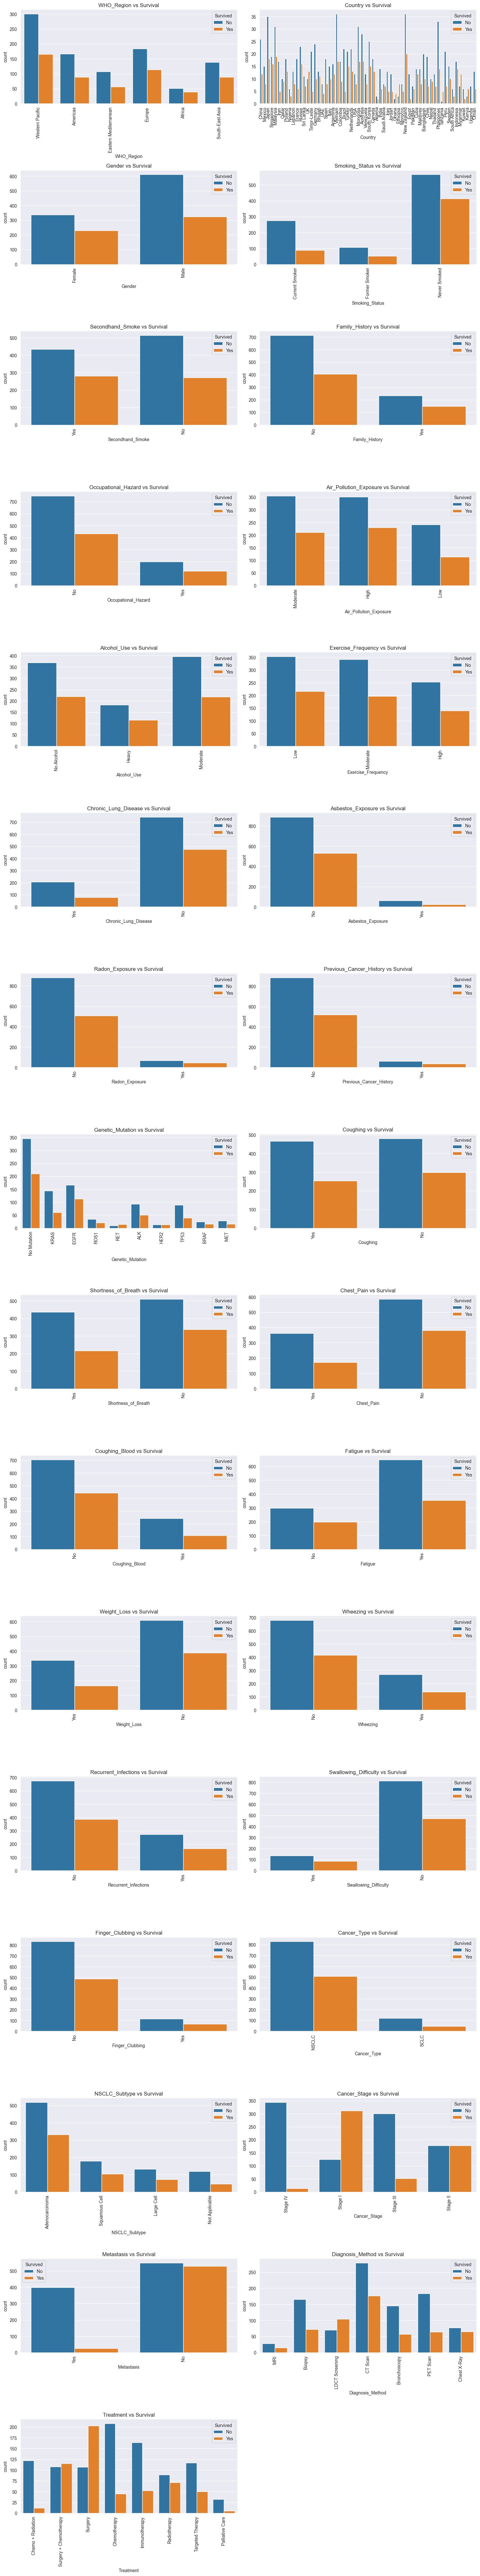

In [22]:
# Select categorical columns (excluding the target variable)
df_categorical = df.select_dtypes(include='object').drop(columns=['Survived'], errors='ignore')

# Get the number of categorical columns
col_count = len(df_categorical.columns)
nrows = (col_count + 1) // 2  # Ensure enough rows for subplots
ncols = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten() if col_count > 1 else [axes]

# Plot each categorical variable against Early_Prediction
for i, column in enumerate(df_categorical.columns):
    sns.countplot(x=df[column], hue=df['Survived'], ax=axes[i])
    axes[i].set_title(f'{column} vs Survival')
    axes[i].tick_params(axis='x', rotation=90)

# Remove unused subplots if the number of categorical columns is odd
if col_count % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Machine Learning
Random Forest Classifier

In [23]:
from sklearn.preprocessing import LabelEncoder

# Initialize the Label Encoder
label_encoder = {}

# Apply the Label Encoder to every categorical column
for col in df_categorical.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoder[col] = le

print(df.head())

   Diagnosis_Year  WHO_Region  Country  Age  Gender  Smoking_Status  \
0            2020           5        8   46       0               0   
1            2020           1       28   71       1               1   
2            2016           5       21   53       0               2   
3            2017           5       44   55       1               0   
4            2023           5       26   54       1               2   

   Cigarettes_Per_Day  Years_Smoking  Secondhand_Smoke  Family_History  ...  \
0                  28             28                 1               0  ...   
1                   5             34                 1               0  ...   
2                   0              0                 1               0  ...   
3                  21             34                 0               1  ...   
4                   0              0                 0               0  ...   

   Finger_Clubbing  Cancer_Type  NSCLC_Subtype  Cancer_Stage  Tumor_Size_cm  \
0                0 

In [24]:
X = df.drop("Survived", axis=1)
Y = df["Survived"]

# Scale fit-transformation
X_scaled = StandardScaler().fit_transform(X)

Splitting data into training and testing parts

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

Training the Model

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Set up the model
rf_model = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist,
                                   n_iter=50, scoring='accuracy', cv=3, verbose=1,
                                   random_state=42, n_jobs=-1)

# Fit the model
random_search.fit(X_train, y_train)

# Get the best parameters and the best score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

# Use the best model to make predictions
best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

# Evaluate the model
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Best Cross-Validation Accuracy: 0.7591666666666667
Test Accuracy: 0.7066666666666667
Classification Report:
               precision    recall  f1-score   support

          No       0.82      0.73      0.77       203
         Yes       0.54      0.66      0.59        97

    accuracy                           0.71       300
   macro avg       0.68      0.69      0.68       300
weighted avg       0.73      0.71      0.71       300



Visualizing the Results and Feature Importances

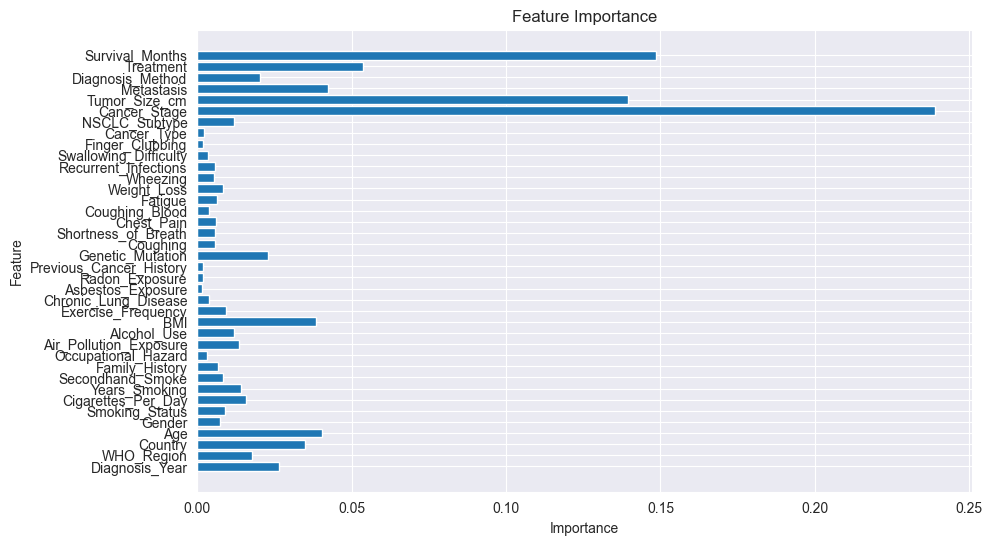

In [27]:
# Feature Importance
feature_importances = best_rf_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()

Saving the Model

In [28]:
import joblib

# Save the model to a file
with open('lung_cancer_model.pkl', 'wb') as model_file:
    joblib.dump(best_rf_model, model_file)

# Conclusion
- The Random Forest Classifier worked decently well with a Test Accuracy of approximately **71%**.
- The **Cancer Stage, Tumour Size, Age, BMI, and Treatment Methods** heavily affected the Survival of a person with Lung Cancer.
- The Survival Months of an affected person have a negative correlation close to **-0.20%** with the number of years that person smoked and the number of cigarettes they take per day, showing how an increase in smoking consumption can decrease chances of survival.
- The Tumour Size of an affected person had a positive correlation close to **0.20%** with the number of years smoked and number of cigarettes taken per day showing that an increase in smoking can lead to an increase in tumour size.
- Affected Patients who did not survive showed positive for these categories: **Low Exercise Frequency, Stage IV Lung Cancer, Fatigue, Coughing blood, Chest pain, Radon Exposure, Shortness of Breath, Coughing, Metastatis, Weight Loss, Wheezing, Genetics Mutations, Alcohol Use and more**
- To increase chances of survival with Lung Cancer, decrease alcohol intake, decrease smoking consumption and take frequent visits to the hospital.